# Cross-model baseline comparison

One run per family - each family's baseline - on the same axes, for CIFAR-100,
CUB-200-2011 and FGVC-Aircraft. The five notebooks in
`notebooks/model_analysis/` compare the arms of a single family against that
family's baseline; this notebook is their transpose, so a panel here carries one
curve per model and what separates the curves is the architecture rather than
the mechanism.

The sections, the code and the figure style are the ones those notebooks use
(`notebooks/utils/hcast_analysis_utils.py`), which is what lets a panel here be
read directly against the same panel there. Baselines normally come from the
shared `FAMILY_PROFILES` registry. This notebook locally replaces the HRN
baseline with `hrn_<dataset>_level_conditional`; the single-family HRN notebook
keeps its own baseline selection.

Three of their eleven sections are deliberately absent, because each measures a
quantity that only exists inside a family. The terms of the aggregate objective
are absent because `total` is a different functional in every family - H-CAST
sums level cross-entropies and a global KL term, HRN a tree loss and a leaf
cross-entropy, HT-CapsNet capsule margins - so those curves would share an axis
without sharing a quantity. The effective level-loss weights are absent because
only some families weight their level objectives at all, so the figure would be
two curves and three empty legend entries. The gradient-support blocks are
absent because which blocks exist is a property of the architecture, and a
figure indexed by them compares different parameter sets between families. All
three are in the family notebooks, where the runs being compared do share an
objective, an architecture and a mechanism.

The notebook then turns to the mechanisms themselves. The sections up to the
test tables compare unmodified architectures; the sections after them ask
whether HCC and the lexicographic step do the same thing to more than one
architecture, which is the question a cross-model page is actually for. That
second half never puts two architectures on a shared axis - it plots each arm
against its own family's baseline - for the reason given where it starts.

## Setup

In [14]:
from dataclasses import replace
from pathlib import Path
import sys

import numpy as np

cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'configs').is_dir()), cwd)
notebook_utils_dir = repo_root / 'notebooks' / 'utils'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

import thesis_style
import hcast_analysis_utils as hu
from hcast_analysis_utils import (
    HCastAnalysis,
    MechanismDeltaComparison,
    resolve_project_root,
    show_markdown,
)

# Choose the families on the page, in legend order. Available family slugs are
# listed by `hu.FAMILY_PROFILES`. The first selected family is the delta baseline
# of every test table below; the rest are the comparison arms.
FAMILIES = [
    'hcast',
    'lhdnn',
    'hrn',
    'ht_capsnet',
    'hiercos',
]

# This cross-model comparison uses HRN's level-conditional objective as its
# baseline without changing the baseline used by the single-family notebook.
hu.FAMILY_PROFILES['hrn'] = replace(
    hu.FAMILY_PROFILES['hrn'],
    baseline_template='hrn_{dataset}_level_conditional',
)

# The mechanisms compared across families in the second half. Every arm each
# family has is registered in `FAMILY_PROFILES[...].mechanism_arms`, so adding
# 'lex_fine_first' here is the only change needed to put it on the page; it is
# left off because only two families have that arm today.
MECHANISMS = ['hcc', 'lex_coarse_first']

# Which decoders every figure and table below shows: 'both', 'independent' or
# 'topdown'. The two decoders do not select the same epoch, so 'both' is the
# default; the other two read the whole page for one decoder and halve the
# curves in every panel. Individual calls can still override it with
# `decoder_view=`.
DECODER_VIEW = hu.set_decoder_view('independent')

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')

# Export the notebook's existing baseline figures directly beside the chapter.
BASELINE_FIGURE_DIR = repo_root / 'docs' / 'images' / 'experiments' / 'baseline'
FIGURE_DIR = hu.set_figure_dir(BASELINE_FIGURE_DIR)

print(f'Project root: {PROJECT_ROOT}')
print('Families:     ' + ', '.join(hu.FAMILY_PROFILES[family].display_name for family in FAMILIES))
print(f'Decoders:     {hu.decoder_view_phrase()} decoding')
print(f'Figures:      {FIGURE_DIR}')

Project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study
Families:     H-CAST, LH-DNN, HRN, HT-CapsNet, Hier-COS
Decoders:     independent decoding
Figures:      /home/g.saggini1/lexicographic_deep_learning_detailed_study/docs/images/experiments/baseline


## Run matrix

One row per family per dataset, with the seeds that entered the mean and the
epoch each decoder selected. The baseline keeps the one fixed baseline colour,
so H-CAST is the blue curve here exactly as it is in its own notebook, and the
other three take the shared palette in the order above - one colour per family,
held across all three datasets.

Two things this listing makes explicit are worth reading before the figures.
Seed counts differ between families, and a single-seed row carries no band and
no standard deviation, so it should not be read against a three-seed mean as
though the two were equally settled. Epoch budgets differ as well, and differ by
design: LH-DNN's schedule is 15 epochs and ends there, while the other three are
configured for 100. A curve that stops early is therefore either that budget or
a run still in flight, and a run still in flight also reports `n/a` in the test
table, since `test_metrics.yaml` is written when the run finishes.

A configured baseline with no readable seed directory - not launched yet, or
renamed since the profile was written - is named explicitly rather than dropped
silently.

In [15]:
analysis = HCastAnalysis.for_baseline_comparison(FAMILIES, OUTPUTS_ROOT)
analysis.print_run_summary()

[cifar-100] H-CAST: epochs=100, best_ind_epoch=97.33333333333333, baseline, seeds=[0, 1, 2]
[cifar-100] LH-DNN: epochs=15, best_ind_epoch=12.666666666666666, seeds=[0, 1, 2]
[cifar-100] HRN: epochs=100, best_ind_epoch=90.33333333333333, seeds=[0, 1, 2]
[cifar-100] HT-CapsNet: epochs=100, best_ind_epoch=97.0, seeds=[0, 1, 2]
[cifar-100] Hier-COS: epochs=100, best_ind_epoch=93.66666666666667, seeds=[0, 1, 2]
[cub-200-2011] H-CAST: epochs=100, best_ind_epoch=82.66666666666667, baseline, seeds=[0, 1, 2]
[cub-200-2011] LH-DNN: epochs=15, best_ind_epoch=12.333333333333334, seeds=[0, 1, 2]
[cub-200-2011] HRN: epochs=100, best_ind_epoch=79.0, seeds=[0, 1, 2]
[cub-200-2011] HT-CapsNet: epochs=100, best_ind_epoch=80.66666666666667, seeds=[0, 1, 2]
[cub-200-2011] Hier-COS: epochs=100, best_ind_epoch=71.66666666666667, seeds=[0, 1, 2]
[fgvc-aircraft] H-CAST: epochs=100, best_ind_epoch=91.66666666666667, baseline, seeds=[0, 1, 2]
[fgvc-aircraft] LH-DNN: epochs=15, best_ind_epoch=12.666666666666666,

## Validation curves

FPA and weighted AP are higher-is-better; AHD and TICE are lower-is-better, and
the arrow in the test table below repeats that. Only independent decoding is
plotted. Colour is the model, the band is one standard deviation across seeds
where more than one seed contributed, and the marker is the independently
selected checkpoint.

The epoch axis is shared by the panel but not by the experiment: the families do
not train on the same schedule, so a curve that reaches a value sooner has not
been shown to converge faster. What is comparable is where each curve ends and
which epoch its own selection rule picked.

**CIFAR-100: validation metrics (independent decoding)**

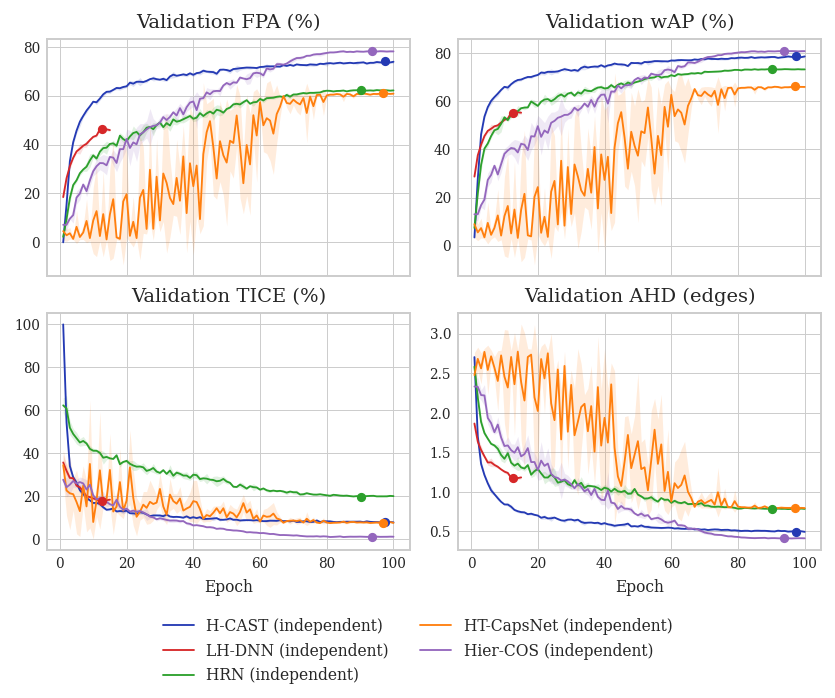

**CUB-200: validation metrics (independent decoding)**

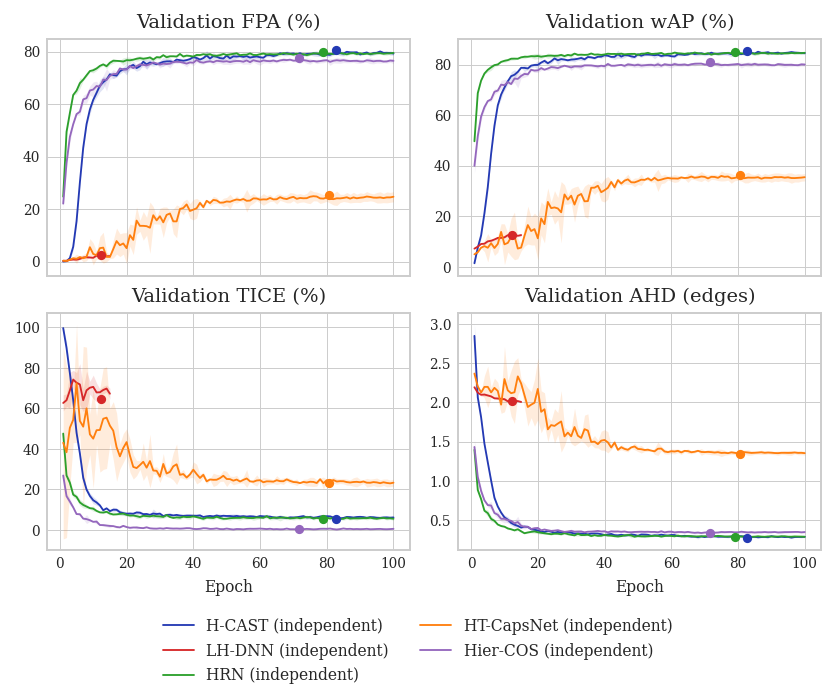

**Aircraft: validation metrics (independent decoding)**

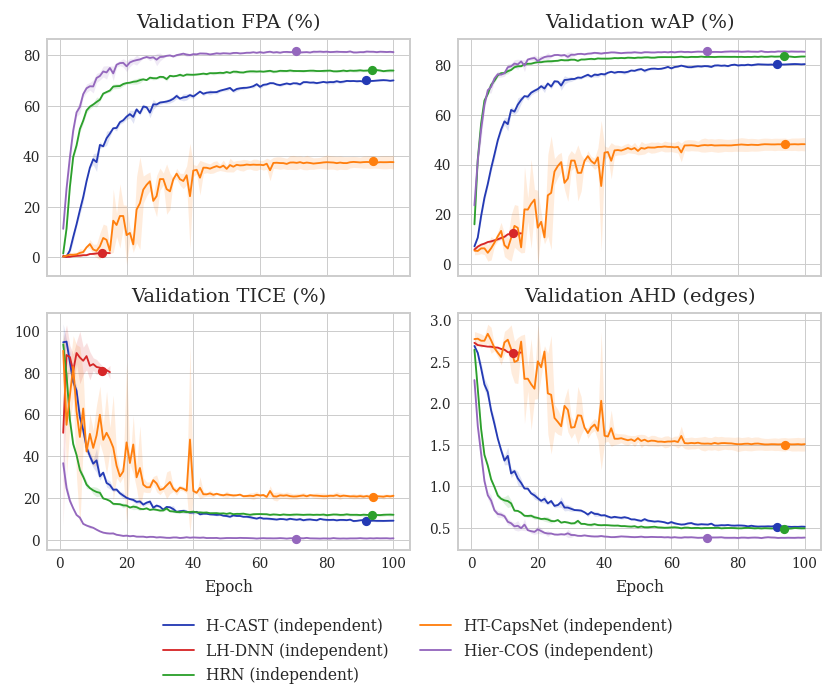

In [16]:
analysis.plot_validation_curves(decoder_view='independent')

## Per-level validation accuracy

The same runs resolved by hierarchy level, coarsest panel first. Read against
the FPA panel above, this separates a model that gained fine accuracy from one
that gained full-path accuracy by repairing its coarse predictions.

Across colours, compare models only within one panel. A level is
the same set of labels for every model on a given dataset, so that comparison is
well posed; comparing a coarse number of one model against a fine number of
another is not.

**CIFAR-100: per-level validation accuracy**

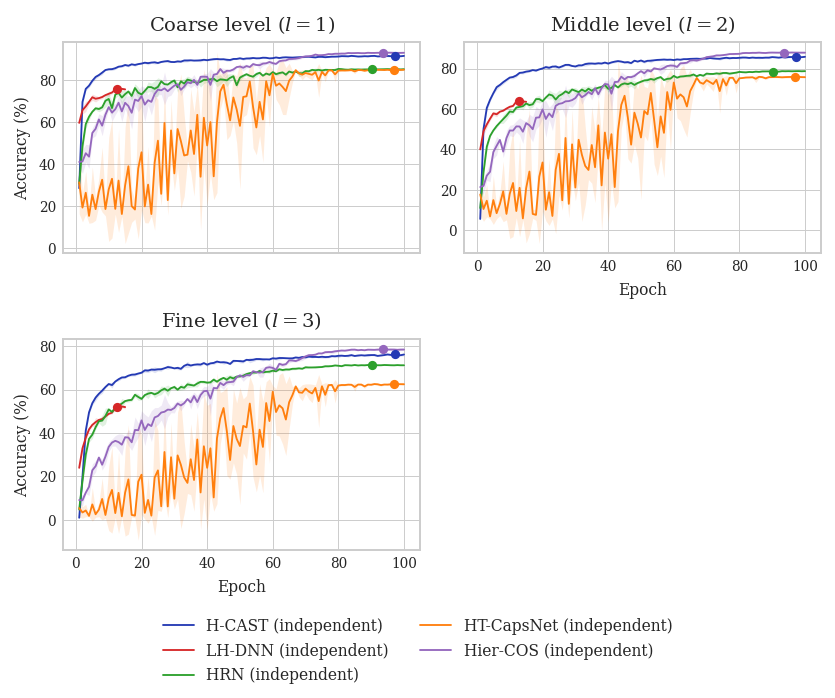

**CUB-200: per-level validation accuracy**

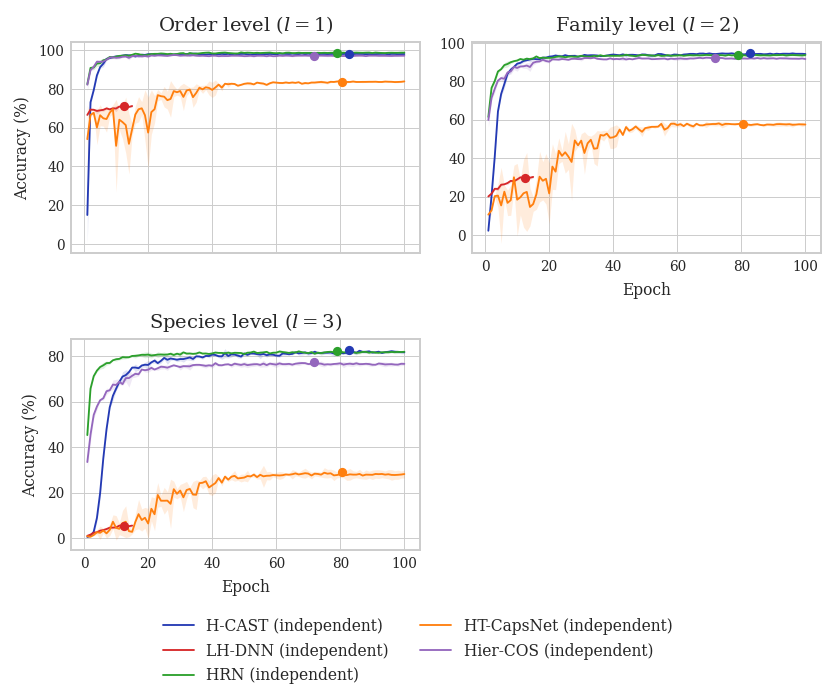

**Aircraft: per-level validation accuracy**

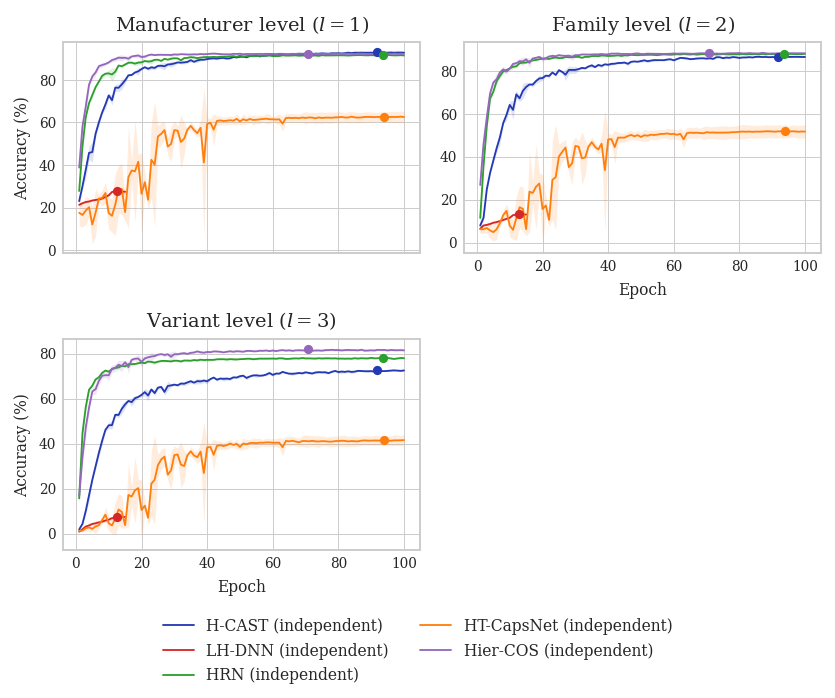

In [17]:
analysis.plot_per_level_validation_accuracy(decoder_view='independent')

## Final selected-checkpoint level accuracy

The three datasets are shown in one row. Points are independent-decoding test
accuracy means at the independently selected checkpoint, error bars are one
sample standard deviation across seeds, and lines connect hierarchy levels
within the same run. The vertical axis is shared and adapts to the visible values and error bars.

**Final selected-checkpoint level accuracy (independent decoding)**

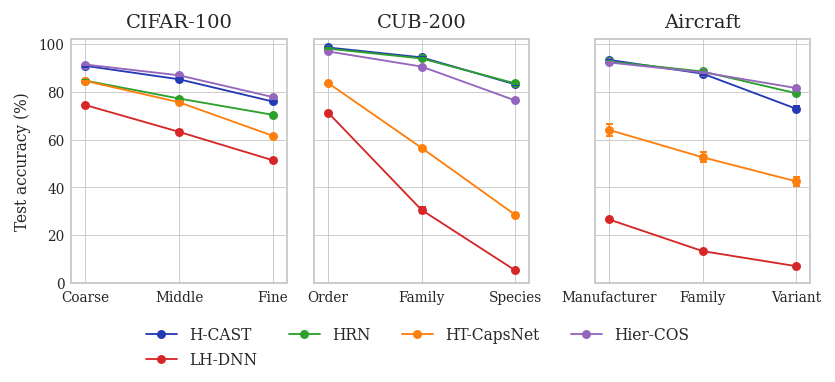

In [18]:
analysis.plot_final_level_test_accuracy(decoder_view='independent')

## Level objectives within each run

One panel per model, with that model's level objectives inside the panel. This
is the one loss section the cross-model page keeps, and it keeps it precisely
because nothing is plotted across families on a shared axis: a capsule margin
loss and a level cross-entropy are not the same number, so what is readable here
is the shape within a panel - which level a model drives down first, and whether
a deep level is being traded against a shallow one - not the height of one panel
against the next.

A model whose objective does not decompose into per-level terms logs no
`loss_level_*` series and is named as absent rather than drawn flat. HRN's plain
baseline is that case: its objective decomposes only under
`model.loss=level_marginal`, which is an arm of its own family notebook and not
the baseline compared here.

[CIFAR-100] per-level curves are shown unweighted: this family folds the level weight into the logged term, so it is divided out here, and the aggregate terms built from those parts are re-summed to match. The weights are the next section, and `total` still carries them because it is the objective.


**CIFAR-100: level objectives within each run**

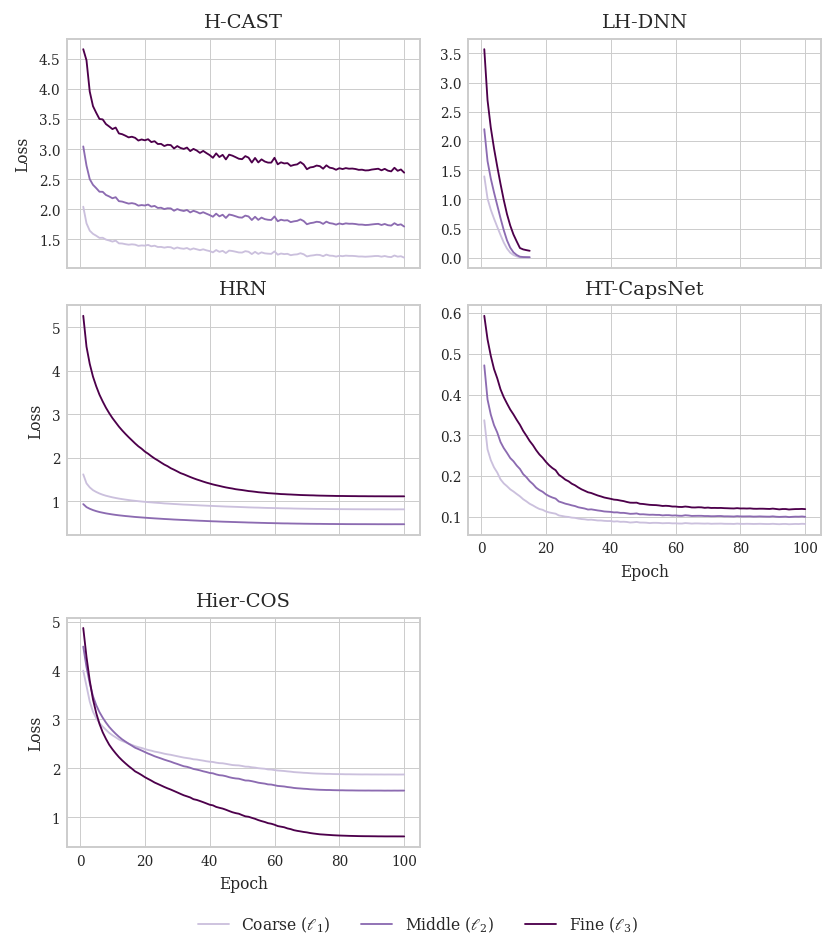

[CUB-200] per-level curves are shown unweighted: this family folds the level weight into the logged term, so it is divided out here, and the aggregate terms built from those parts are re-summed to match. The weights are the next section, and `total` still carries them because it is the objective.


**CUB-200: level objectives within each run**

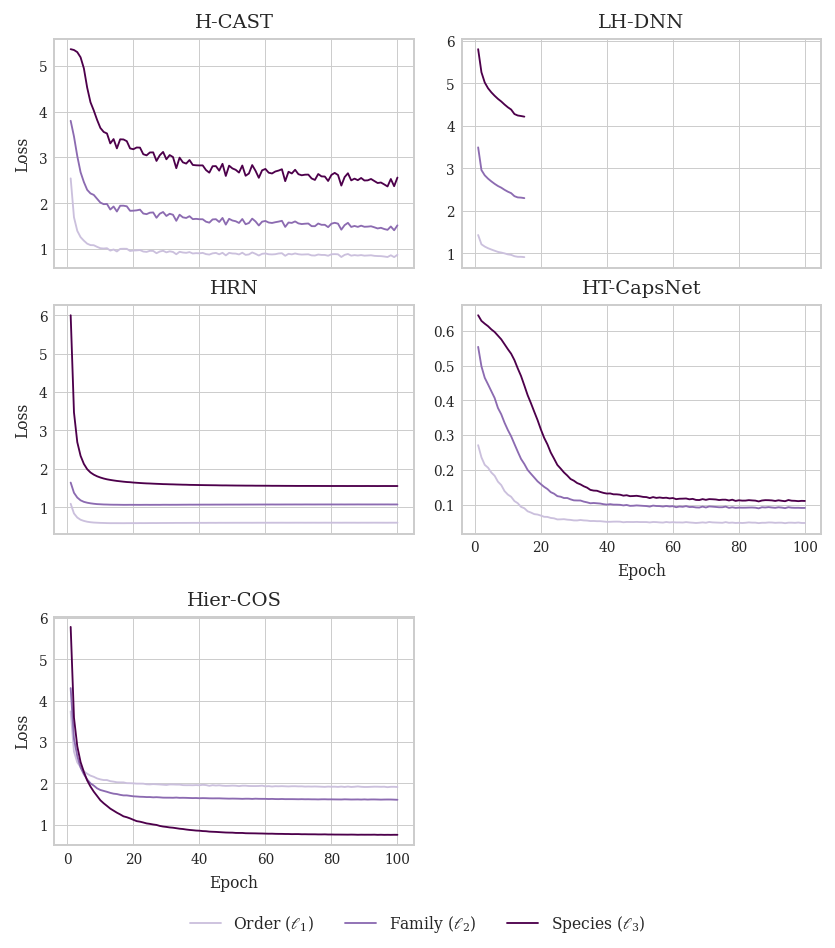

[Aircraft] per-level curves are shown unweighted: this family folds the level weight into the logged term, so it is divided out here, and the aggregate terms built from those parts are re-summed to match. The weights are the next section, and `total` still carries them because it is the objective.


**Aircraft: level objectives within each run**

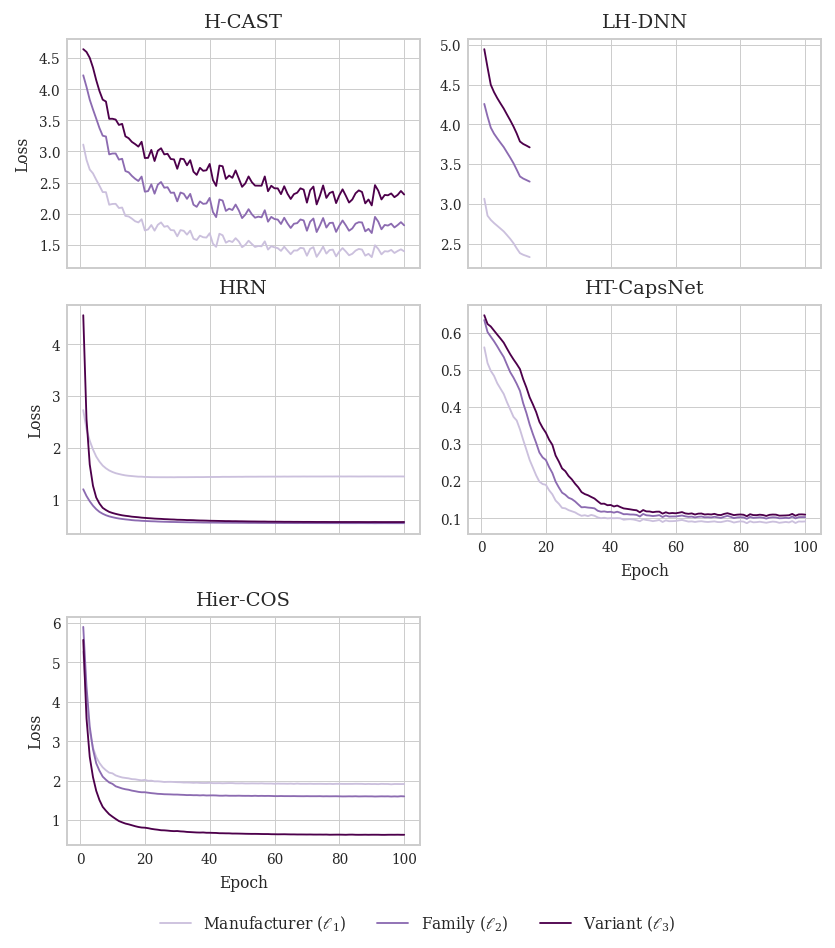

In [19]:
analysis.plot_per_run_per_level_training_losses()

## Output-space constraint diagnostics

The same shared panel list as the family notebooks, `MECHANISM_DIAGNOSTIC_SPECS`,
under the same three filters: a panel is dropped when no selected run logs the
key, when its value is the same constant in every run, and when it traces the
identical curve to a panel already on the page.

Here those filters do most of the work, and what they remove is the point. Every
run on this page is an unconstrained baseline, so nothing rewrote the scores:
the projection panels pin at zero or duplicate their own "before" panel and drop
out, and the printed lines above the figure name each one. That the section
survives at all is therefore a check that no baseline is quietly running a
mechanism.

What is left is structural rather than mechanistic, and it is a real cross-model
comparison: how much fine probability mass a model puts under the true parent,
where the true class ranks among its siblings, and how accurate the fine level is
when the parent is already correct, under each decoder. Those describe the
hierarchy each architecture learned on its own, with no correction applied to
it - which is what separates a model that is hierarchically consistent from one
that is merely accurate at the leaf.

10 figures exported (authored size, in inches):
  comparison_cifar100_validation_curves                5.91 x 4.88
  comparison_cub200_validation_curves                  5.91 x 4.88
  comparison_aircraft_validation_curves                5.91 x 4.88
  comparison_cifar100_per_level_accuracy               5.91 x 4.88
  comparison_cub200_per_level_accuracy                 5.91 x 4.88
  comparison_aircraft_per_level_accuracy               5.91 x 4.88
  comparison_final_level_accuracy                      5.91 x 2.63
  comparison_cifar100_level_losses_per_run             5.91 x 6.68
  comparison_cub200_level_losses_per_run               5.91 x 6.68
  comparison_aircraft_level_losses_per_run             5.91 x 6.68
[CIFAR-100] constant in every selected run, so not plotted: Total fine probability shift (held at 0); True-class fine probability shift (held at 0); Fine prediction flip rate (held at 0).
[CIFAR-100] duplicates a panel already on this page, so not plotted: Fine mass under the true 

**CIFAR-100: output-space constraint diagnostics**

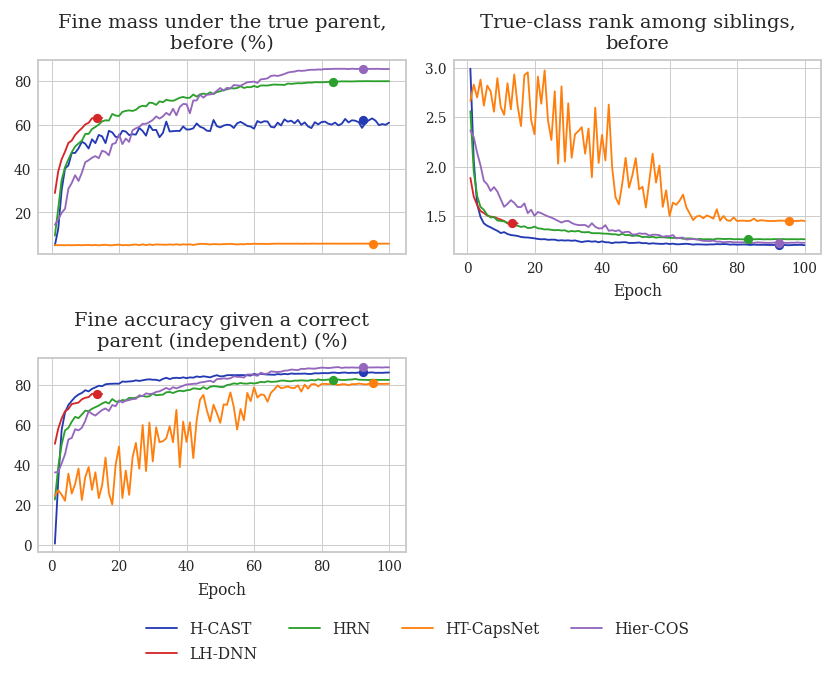

[CUB-200] constant in every selected run, so not plotted: Total fine probability shift (held at 0); True-class fine probability shift (held at 0); Fine prediction flip rate (held at 0).
[CUB-200] duplicates a panel already on this page, so not plotted: Fine mass under the true parent, after (identical to Fine mass under the true parent, before); True-class rank among siblings, after (identical to True-class rank among siblings, before).


**CUB-200: output-space constraint diagnostics**

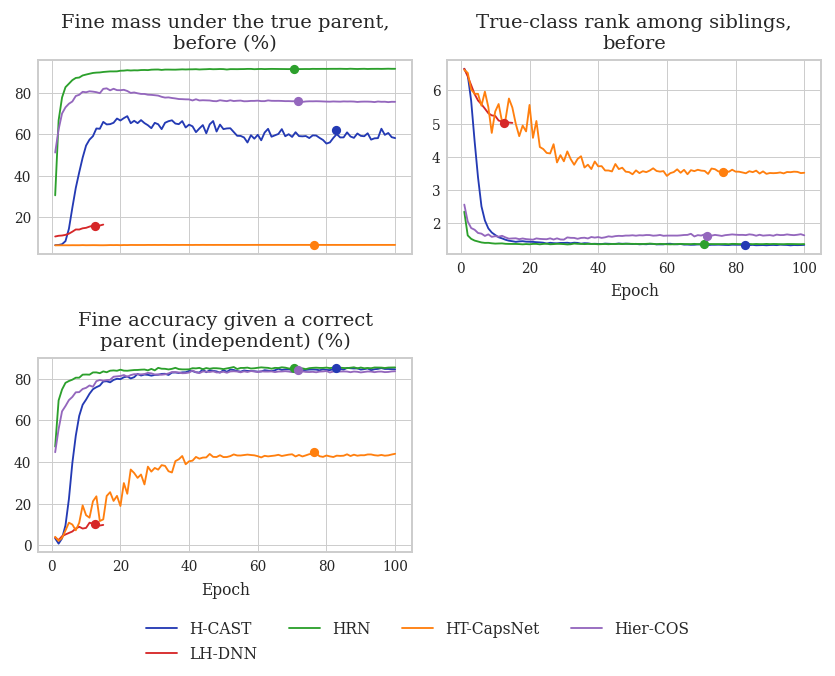

[Aircraft] constant in every selected run, so not plotted: Total fine probability shift (held at 0); True-class fine probability shift (held at 0); Fine prediction flip rate (held at 0).
[Aircraft] duplicates a panel already on this page, so not plotted: Fine mass under the true parent, after (identical to Fine mass under the true parent, before); True-class rank among siblings, after (identical to True-class rank among siblings, before).


**Aircraft: output-space constraint diagnostics**

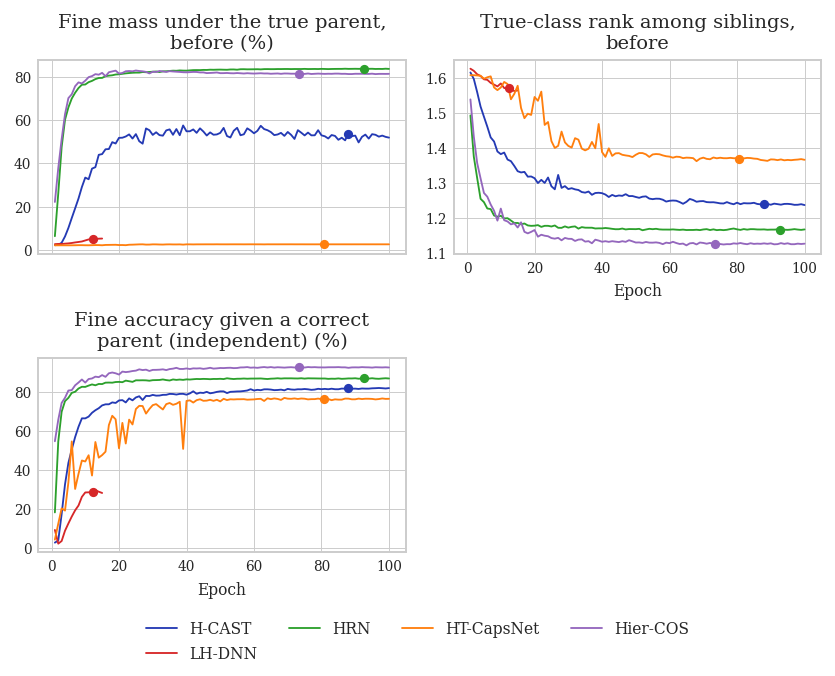

In [20]:
BASELINE_EXPORTED_FIGURES = list(hu.EXPORTED_FIGURES)
thesis_style.report_exported(BASELINE_EXPORTED_FIGURES)

# Keep diagnostics and later mechanism-delta figures as runtime artifacts.
MECHANISM_FIGURE_DIR = OUTPUTS_ROOT / 'analysis' / 'model_analysis' / 'comparison' / 'figures'
FIGURE_DIR = hu.set_figure_dir(MECHANISM_FIGURE_DIR)
analysis.plot_projection_diagnostics()

## Final selected-checkpoint test tables

Test metrics read from `test_metrics.yaml` under independent decoding, at the
independently selected checkpoint. Cells are mean ± standard
deviation over the seeds named in the run matrix; deltas are against H-CAST, in
percentage points for percentages and in edges for AHD. The best value in a row
is bold and the second best underlined.

Two rows are degenerate by construction rather than by accident of these runs,
and are tabulated anyway because the identity is worth showing: TICE under
top-down decoding is zero, because that decoder enforces consistency, and
full-path accuracy under top-down decoding equals the fine-level accuracy,
because a correct leaf there implies a correct path. A value that departs from
either is a bug, not a result.

Two settings on this page are local extrapolations rather than paper-aligned
ones - HRN on CIFAR-100 and Hier-COS on CUB-200 - and the hierarchy used for
CIFAR-100 is this repository's choice. Their rows are produced under the same
protocol as the rest of the table, but they are not the number their paper
reports, and a delta involving them measures this repository's setting rather
than a published result.

In [21]:
analysis.show_final_test_tables(allow_single_run=True)

### Dataset: `cifar-100`
Baseline run: **H-CAST**

| Metric | H-CAST (n=3) | LH-DNN (n=3) | HRN (n=3) | HT-CapsNet (n=3) | Hier-COS (n=3) |
|---|---:|---:|---:|---:|---:|
| Best epoch (Ind) | 97.3 ± 2.3 | 12.7 ± 1.2 | 90.3 ± 0.6 | 97.0 ± 2.6 | 93.7 ± 5.0 |
| FPA (independent) ↑ | <u>73.48% ± 0.19%</u> | 45.57% ± 0.48% (-27.91 pp) | 61.76% ± 0.34% (-11.72 pp) | 59.87% ± 0.21% (-13.61 pp) | **77.52% ± 0.16% (+4.04 pp)** |
| wAP (independent) ↑ | <u>78.31% ± 0.14%</u> | 54.69% ± 0.58% (-23.62 pp) | 72.33% ± 0.19% (-5.98 pp) | 65.24% ± 0.04% (-13.08 pp) | **80.07% ± 0.20% (+1.75 pp)** |
| TICE (independent) ↓ | <u>7.61% ± 0.29%</u> | 17.90% ± 0.44% (+10.28 pp) | 20.45% ± 0.17% (+12.84 pp) | 7.63% ± 0.43% (+0.01 pp) | **1.04% ± 0.04% (-6.57 pp)** |
| AHD (independent) ↓ | <u>0.511 ± 0.008</u> | 1.199 ± 0.015 (+0.689) | 0.804 ± 0.006 (+0.293) | 0.809 ± 0.002 (+0.298) | **0.444 ± 0.003 (-0.067)** |
| Coarse accuracy (independent) ↑ | <u>90.82% ± 0.32%</u> | 74.43% ± 0.49% (-16.39 pp) | 84.65% ± 0.12% (-6.17 pp) | 84.52% ± 0.02% (-6.30 pp) | **91.35% ± 0.06% (+0.53 pp)** |
| Middle accuracy (independent) ↑ | <u>85.20% ± 0.39%</u> | 63.25% ± 0.65% (-21.96 pp) | 77.16% ± 0.12% (-8.04 pp) | 75.61% ± 0.10% (-9.59 pp) | **86.87% ± 0.21% (+1.66 pp)** |
| Fine accuracy (independent) ↑ | <u>75.94% ± 0.20%</u> | 51.40% ± 0.58% (-24.53 pp) | 70.38% ± 0.24% (-5.56 pp) | 61.62% ± 0.03% (-14.32 pp) | **77.80% ± 0.21% (+1.87 pp)** |

### Dataset: `cub-200-2011`
Baseline run: **H-CAST**

| Metric | H-CAST (n=3) | LH-DNN (n=3) | HRN (n=3) | HT-CapsNet (n=3) | Hier-COS (n=3) |
|---|---:|---:|---:|---:|---:|
| Best epoch (Ind) | 82.7 ± 14.0 | 12.3 ± 2.3 | 79.0 ± 23.6 | 80.7 ± 17.2 | 71.7 ± 16.3 |
| FPA (independent) ↑ | **81.27% ± 0.33%** | 2.33% ± 0.23% (-78.94 pp) | <u>80.56% ± 0.29% (-0.71 pp)</u> | 24.48% ± 0.74% (-56.79 pp) | 76.15% ± 0.42% (-5.12 pp) |
| wAP (independent) ↑ | <u>85.59% ± 0.13%</u> | 12.64% ± 0.61% (-72.95 pp) | **85.82% ± 0.10% (+0.23 pp)** | 35.68% ± 0.79% (-49.91 pp) | 79.58% ± 0.34% (-6.01 pp) |
| TICE (independent) ↓ | <u>5.24% ± 0.41%</u> | 63.05% ± 1.97% (+57.82 pp) | 6.21% ± 0.14% (+0.97 pp) | 24.43% ± 1.09% (+19.20 pp) | **0.60% ± 0.19% (-4.64 pp)** |
| AHD (independent) ↓ | **0.262 ± 0.002** | 1.996 ± 0.015 (+1.734) | <u>0.285 ± 0.009 (+0.024)</u> | 1.372 ± 0.010 (+1.111) | 0.366 ± 0.006 (+0.104) |
| Order accuracy (independent) ↑ | **98.49% ± 0.14%** | 71.30% ± 0.54% (-27.19 pp) | <u>98.00% ± 0.30% (-0.49 pp)</u> | 83.67% ± 0.20% (-14.83 pp) | 96.85% ± 0.11% (-1.65 pp) |
| Family accuracy (independent) ↑ | **94.36% ± 0.11%** | 30.62% ± 1.09% (-63.73 pp) | <u>93.91% ± 0.22% (-0.45 pp)</u> | 56.56% ± 0.54% (-37.80 pp) | 90.51% ± 0.13% (-3.84 pp) |
| Species accuracy (independent) ↑ | <u>83.09% ± 0.16%</u> | 5.41% ± 0.55% (-77.68 pp) | **83.49% ± 0.10% (+0.41 pp)** | 28.60% ± 0.93% (-54.49 pp) | 76.38% ± 0.41% (-6.70 pp) |

### Dataset: `fgvc-aircraft`
Baseline run: **H-CAST**

| Metric | H-CAST (n=3) | LH-DNN (n=3) | HRN (n=3) | HT-CapsNet (n=3) | Hier-COS (n=3) |
|---|---:|---:|---:|---:|---:|
| Best epoch (Ind) | 91.7 ± 5.5 | 12.7 ± 1.5 | 93.7 ± 3.2 | 94.0 ± 6.0 | 70.7 ± 11.0 |
| FPA (independent) ↑ | 70.73% ± 1.04% | 1.96% ± 0.23% (-68.77 pp) | <u>75.65% ± 0.24% (+4.92 pp)</u> | 39.03% ± 2.06% (-31.69 pp) | **81.40% ± 0.52% (+10.67 pp)** |
| wAP (independent) ↑ | 81.09% ± 0.61% | 12.26% ± 0.20% (-68.83 pp) | <u>84.54% ± 0.24% (+3.45 pp)</u> | 49.31% ± 2.07% (-31.78 pp) | **85.44% ± 0.37% (+4.35 pp)** |
| TICE (independent) ↓ | <u>9.09% ± 0.10%</u> | 80.71% ± 1.31% (+71.62 pp) | 11.21% ± 0.18% (+2.12 pp) | 20.28% ± 1.21% (+11.19 pp) | **0.78% ± 0.13% (-8.31 pp)** |
| AHD (independent) ↓ | 0.492 ± 0.013 | 2.615 ± 0.004 (+2.123) | <u>0.460 ± 0.009 (-0.032)</u> | 1.467 ± 0.069 (+0.976) | **0.384 ± 0.008 (-0.108)** |
| Manufacturer accuracy (independent) ↑ | **93.31% ± 0.12%** | 26.65% ± 0.49% (-66.66 pp) | <u>92.64% ± 0.37% (-0.67 pp)</u> | 64.06% ± 2.49% (-29.25 pp) | 92.22% ± 0.05% (-1.09 pp) |
| Family accuracy (independent) ↑ | 87.57% ± 0.51% | 13.42% ± 0.17% (-74.15 pp) | **88.46% ± 0.43% (+0.89 pp)** | 52.63% ± 2.13% (-34.94 pp) | <u>88.10% ± 0.33% (+0.53 pp)</u> |
| Variant accuracy (independent) ↑ | 72.90% ± 1.05% | 7.13% ± 0.37% (-65.77 pp) | <u>79.37% ± 0.24% (+6.47 pp)</u> | 42.56% ± 1.92% (-30.33 pp) | **81.55% ± 0.52% (+8.65 pp)** |

## Cross-model mechanism deltas

The sections above compare architectures. These compare *mechanisms across*
architectures: does HCC, or the lexicographic step, do the same thing to more
than one model?

Not on a shared axis, though. H-CAST and Hier-COS are four points of FPA apart
on CIFAR-100 and eleven on Aircraft, so a mechanism worth well under one point
would be invisible next to the gap between the models carrying it. What survives
that gap is the paired difference: each arm against its **own** family's
baseline, which is the only comparison holding the architecture fixed while the
mechanism changes. Every number below is such a difference.

The pairing is per seed rather than between two aggregates. Seed *s* of the arm
and seed *s* of its baseline share an initialisation and a data order, so
differencing them first cancels the seed-to-seed variance that sits in both
means. The spread reported is therefore the spread of the *effect* across seeds,
which is what decides whether an effect is there at all, and it is usually much
smaller than the spread of either run alone.

The listing below says which pairs were formed and on how many seeds, then names
what could not be paired: a family with no arm registered for a mechanism, an arm
with no readable seed directory, and an arm whose seeds do not overlap its
baseline's are three different situations, and letting all three show up as a
missing curve would let "does not apply here" read as "did nothing here".

In [22]:
mechanisms = MechanismDeltaComparison.for_mechanisms(MECHANISMS, FAMILIES, OUTPUTS_ROOT)
mechanisms.print_pair_summary()

HCC: 2 family/families with a delta (H-CAST, Hier-COS)
    [CIFAR-100] H-CAST: 3 paired seed(s) [0, 1, 2]
    [CIFAR-100] Hier-COS: 3 paired seed(s) [0, 1, 2]
    [CUB-200] H-CAST: 3 paired seed(s) [0, 1, 2]
    [CUB-200] Hier-COS: 3 paired seed(s) [0, 1, 2]
    [Aircraft] H-CAST: 3 paired seed(s) [0, 1, 2]
    [Aircraft] Hier-COS: 3 paired seed(s) [0, 1, 2]
Lexicographic (coarse-first): 3 family/families with a delta (H-CAST, HT-CapsNet, Hier-COS)
    [CIFAR-100] H-CAST: 3 paired seed(s) [0, 1, 2]
    [CIFAR-100] HT-CapsNet: 1 paired seed(s) [0], unpaired seeds [1, 2]
    [CIFAR-100] Hier-COS: 3 paired seed(s) [0, 1, 2]
    [CUB-200] H-CAST: 3 paired seed(s) [0, 1, 2]
    [CUB-200] HT-CapsNet: 1 paired seed(s) [0], unpaired seeds [1, 2]
    [CUB-200] Hier-COS: 3 paired seed(s) [0, 1, 2]
    [Aircraft] H-CAST: 3 paired seed(s) [0, 1, 2]
    [Aircraft] Hier-COS: 3 paired seed(s) [0, 1, 2]

Not compared:
    LH-DNN has no HCC arm registered, so it contributes no curve to that mechanism.


## What else changed with the mechanism

A delta is about the mechanism only if the mechanism is the only thing that
changed, and that is a property of the two resolved configs, not of the run
names. This section diffs them and prints every key that differs, so the reader
sees the mechanism's own switch and anything travelling with it.

Some arms cannot isolate the mechanism even in principle. H-CAST's lexicographic
mode requires `model.loss.globalkl: false`, so its lex arm necessarily also drops
the global KL term its baseline trains with, and that delta is "lexicographic
step *and* no global KL" rather than the step alone. Others carry a second change
because of how they were launched - an HRN arm also switches the objective to
`level_marginal`, which its baseline does not use. Reading this section before
the figures is what keeps those from being attributed to the mechanism.

In [23]:
mechanisms.report_arm_config_differences()

[CIFAR-100] H-CAST HCC vs its baseline: 3 differing config key(s)
    hcc.enabled: None -> True
    hcc.eps: None -> 1e-12
    train.gradient_blocks: None -> ['p123', 'p12', 'p1']
[CIFAR-100] Hier-COS HCC vs its baseline: 4 differing config key(s)
    hcc.enabled: None -> True
    hcc.eps: None -> 1e-12
    model.projection.enabled: None -> False
    train.gradient_blocks: None -> ['p123']
[CIFAR-100] H-CAST Lexicographic (coarse-first) vs its baseline: 6 differing config key(s)
    model.loss.globalkl: True -> False
    train.lexicographic.enabled: False -> True
    train.lexicographic.eps: None -> 1e-12
    train.lexicographic.log_metrics: None -> True
    train.lexicographic.projection_mode: None -> 'coarse_first'
    train.lexicographic.projection_rule: None -> 'orthogonalize_all'
[CIFAR-100] HT-CapsNet Lexicographic (coarse-first) vs its baseline: 6 differing config key(s)
    model.loss.weight_mode: 'dynamic' -> 'none'
    train.gradient_blocks: ['p123', 'p23', 'p3'] -> ['p123', 

## Mechanism delta curves

One figure per dataset per mechanism. Colour is the family and line style is the
decoder, the same convention as everywhere else here, so only the quantity on the
y axis has changed. The rule at zero is the baseline: a curve above it means the
arm scored higher than its own baseline at that epoch, which is an improvement
for FPA and weighted AP and a regression for TICE and AHD - each axis label
carries its direction, so the sign is never read alone.

The band is one standard deviation of the per-seed differences. A band that
straddles zero is a mechanism whose sign is not settled across seeds, and that
reading is the main thing these panels are for. A mechanism that transfers puts
every family's curve on the same side of zero; one that is a fact about a single
architecture does not.

Two shapes to expect. An arm that changes the objective as well as the mechanism
shows a large transient over the first epochs, which compresses the panel and
says more about the objective switch than about the mechanism - the late epochs
are where the mechanism reads. And an arm still training simply ends early, since
a pair contributes only the epochs both of its runs have logged.

**CIFAR-100: HCC against each family's own baseline**

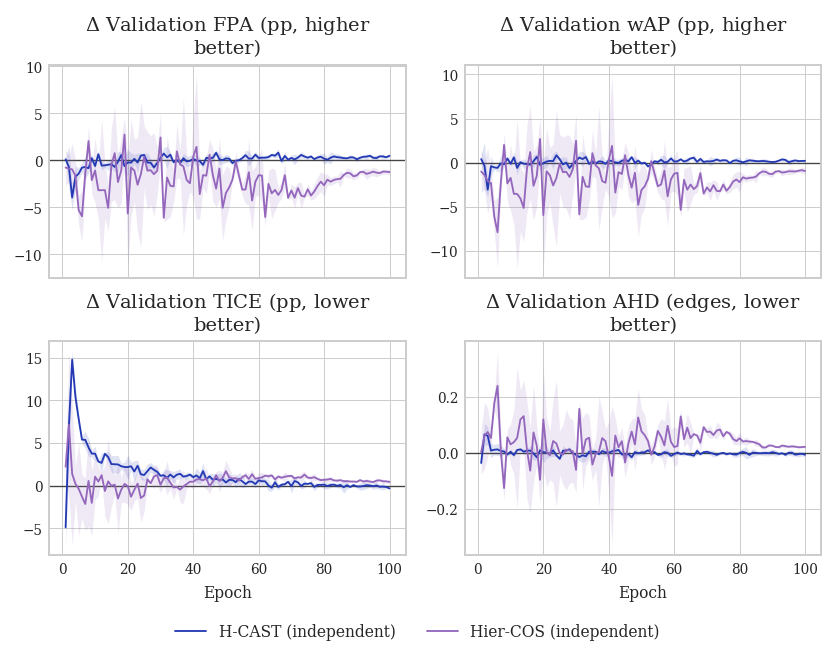

**CIFAR-100: Lexicographic (coarse-first) against each family's own baseline**

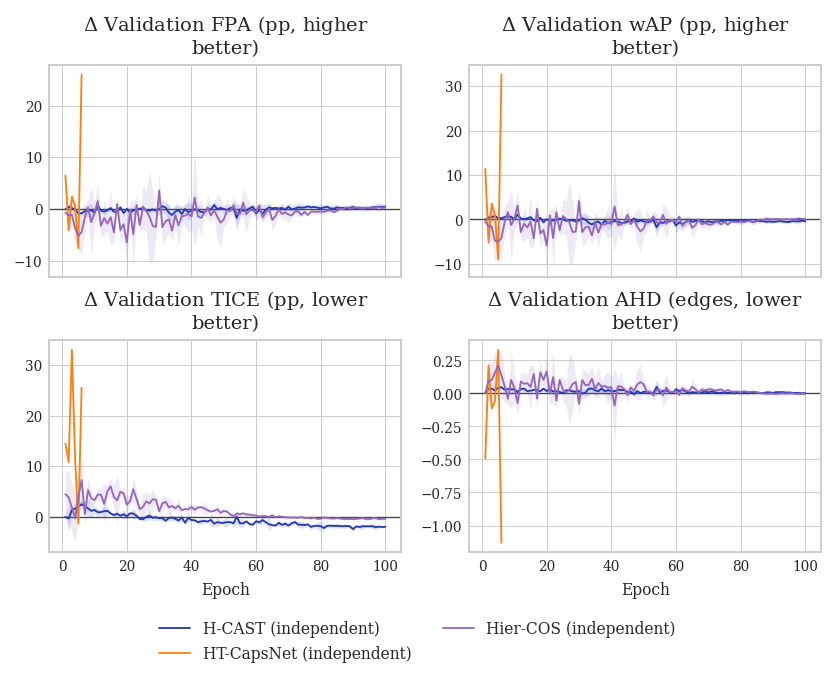

**CUB-200: HCC against each family's own baseline**

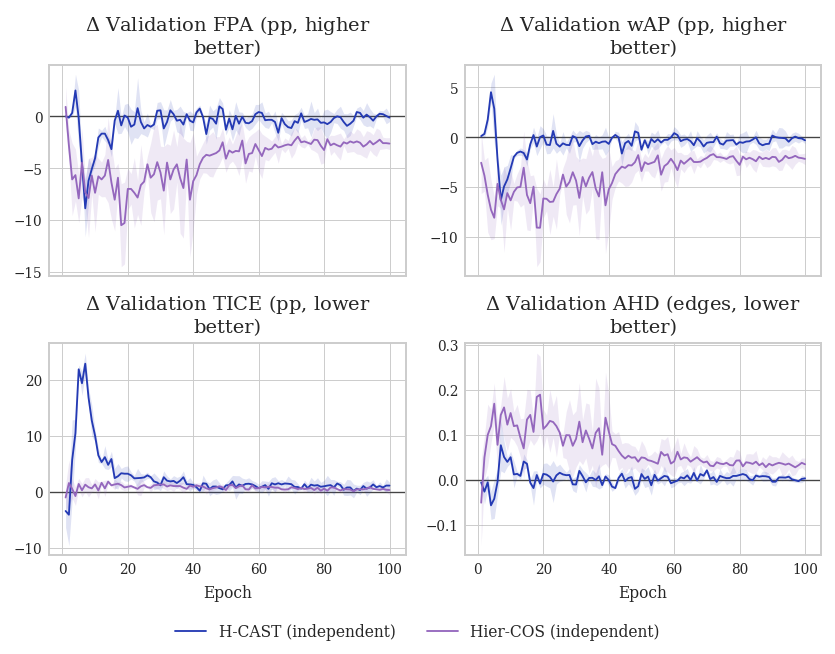

**CUB-200: Lexicographic (coarse-first) against each family's own baseline**

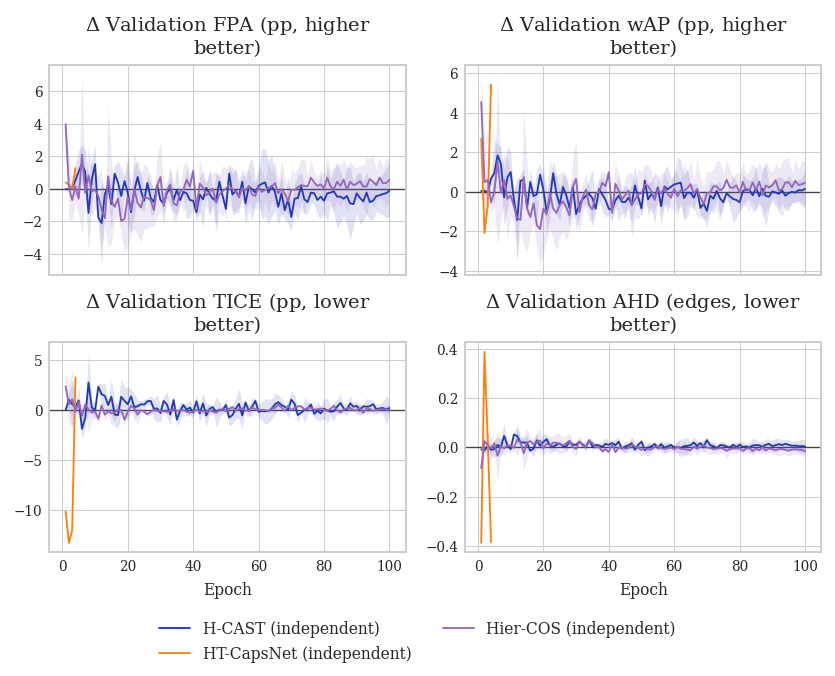

**Aircraft: HCC against each family's own baseline**

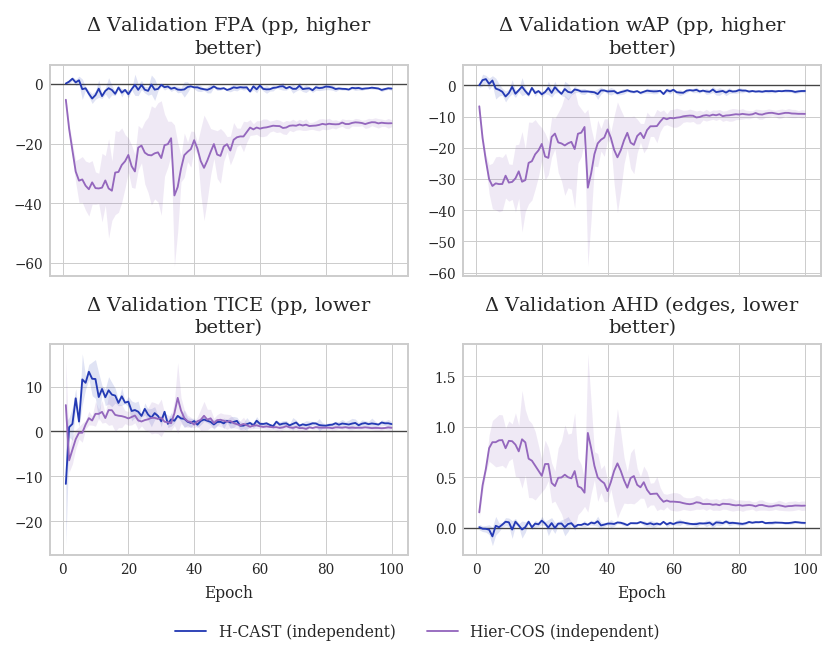

**Aircraft: Lexicographic (coarse-first) against each family's own baseline**

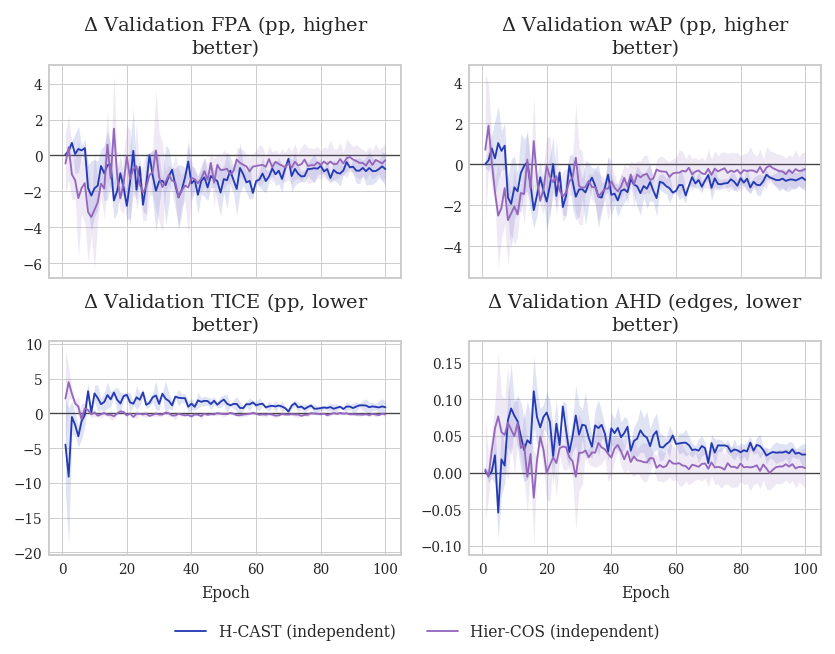

In [24]:
mechanisms.plot_delta_curves()

## Mechanism delta test tables

The same differences at the selected checkpoints, per seed. Each seed contributes
its arm value minus its baseline value, both read at that seed's own checkpoint
for that row's decoder, so the mode-matched selection rule holds inside every
term of every difference rather than only across the table.

Columns are grouped by mechanism, so "did this mechanism do the same thing to two
architectures" is read across a group. Nothing is ranked and nothing is bold:
these are differences of different models, not competitors on one axis. The
useful reading is the sign, whether it is larger than the spread beside it, and
whether it agrees across the families in the group.

In [25]:
mechanisms.show_delta_tables()

### Dataset: `cifar-100`
Each cell is the arm minus that family's own baseline, paired by seed.

| Metric | HCC<br>H-CAST (n=3) | HCC<br>Hier-COS (n=3) | Lexicographic (coarse-first)<br>H-CAST (n=3) | Lexicographic (coarse-first)<br>HT-CapsNet (n=1) | Lexicographic (coarse-first)<br>Hier-COS (n=3) |
|---|---:|---:|---:|---:|---:|
| FPA (independent) ↑ | +0.21 pp ± 0.48 | -1.46 pp ± 0.36 | +0.60 pp ± 0.14 | n/a | -0.20 pp ± 0.35 |
| wAP (independent) ↑ | +0.11 pp ± 0.22 | -1.09 pp ± 0.31 | -0.21 pp ± 0.10 | n/a | -0.26 pp ± 0.38 |
| TICE (independent) ↓ | +0.50 pp ± 0.61 | +0.48 pp ± 0.10 | -1.75 pp ± 0.25 | n/a | -0.46 pp ± 0.07 |
| AHD (independent) ↓ | -0.001 ± 0.012 | +0.020 ± 0.003 | -0.004 ± 0.010 | n/a | +0.002 ± 0.007 |
| Coarse accuracy (independent) ↑ | -0.11 pp ± 0.38 | -0.07 pp ± 0.17 | -0.21 pp ± 0.45 | n/a | +0.01 pp ± 0.11 |
| Middle accuracy (independent) ↑ | +0.01 pp ± 0.31 | -0.41 pp ± 0.31 | -0.19 pp ± 0.51 | n/a | -0.06 pp ± 0.35 |
| Fine accuracy (independent) ↑ | +0.14 pp ± 0.21 | -1.31 pp ± 0.39 | -0.22 pp ± 0.10 | n/a | -0.32 pp ± 0.41 |

A delta is an improvement when its sign matches the arrow in its row: positive for FPA, wAP and the per-level accuracies, negative for TICE and AHD. The spread is the standard deviation of the per-seed differences, so a delta smaller than the number beside it has not been shown to differ from zero on these seeds. `n/a` is a metric one of the two runs has not written yet.

### Dataset: `cub-200-2011`
Each cell is the arm minus that family's own baseline, paired by seed.

| Metric | HCC<br>H-CAST (n=3) | HCC<br>Hier-COS (n=3) | Lexicographic (coarse-first)<br>H-CAST (n=3) | Lexicographic (coarse-first)<br>HT-CapsNet (n=1) | Lexicographic (coarse-first)<br>Hier-COS (n=3) |
|---|---:|---:|---:|---:|---:|
| FPA (independent) ↑ | -0.93 pp ± 0.27 | -3.27 pp ± 0.94 | -0.32 pp ± 0.68 | n/a | +0.30 pp ± 0.81 |
| wAP (independent) ↑ | -0.70 pp ± 0.23 | -2.61 pp ± 0.79 | -0.10 pp ± 0.42 | n/a | +0.26 pp ± 0.67 |
| TICE (independent) ↓ | +0.98 pp ± 0.41 | +0.45 pp ± 0.36 | +0.37 pp ± 0.46 | n/a | -0.18 pp ± 0.23 |
| AHD (independent) ↓ | +0.010 ± 0.004 | +0.042 ± 0.018 | +0.008 ± 0.007 | n/a | -0.012 ± 0.009 |
| Order accuracy (independent) ↑ | +0.03 pp ± 0.12 | -0.42 pp ± 0.30 | -0.16 pp ± 0.14 | n/a | +0.17 pp ± 0.03 |
| Family accuracy (independent) ↑ | -0.11 pp ± 0.20 | -0.50 pp ± 0.74 | -0.27 pp ± 0.33 | n/a | +0.62 pp ± 0.17 |
| Species accuracy (independent) ↑ | -0.86 pp ± 0.29 | -3.16 pp ± 0.88 | -0.06 pp ± 0.49 | n/a | +0.20 pp ± 0.83 |

A delta is an improvement when its sign matches the arrow in its row: positive for FPA, wAP and the per-level accuracies, negative for TICE and AHD. The spread is the standard deviation of the per-seed differences, so a delta smaller than the number beside it has not been shown to differ from zero on these seeds. `n/a` is a metric one of the two runs has not written yet.

### Dataset: `fgvc-aircraft`
Each cell is the arm minus that family's own baseline, paired by seed.

| Metric | HCC<br>H-CAST (n=3) | HCC<br>Hier-COS (n=3) | Lexicographic (coarse-first)<br>H-CAST (n=3) | Lexicographic (coarse-first)<br>Hier-COS (n=3) |
|---|---:|---:|---:|---:|
| FPA (independent) ↑ | -1.04 pp ± 1.15 | -12.91 pp ± 0.65 | -1.12 pp ± 0.36 | -0.13 pp ± 0.91 |
| wAP (independent) ↑ | -1.56 pp ± 0.64 | -8.95 pp ± 1.23 | -0.98 pp ± 0.15 | -0.10 pp ± 0.75 |
| TICE (independent) ↓ | +0.81 pp ± 0.42 | +0.61 pp ± 0.70 | +0.65 pp ± 0.29 | -0.19 pp ± 0.15 |
| AHD (independent) ↓ | +0.037 ± 0.015 | +0.213 ± 0.044 | +0.037 ± 0.001 | +0.001 ± 0.019 |
| Manufacturer accuracy (independent) ↑ | -0.83 pp ± 0.27 | -2.08 pp ± 1.62 | -0.77 pp ± 0.22 | +0.04 pp ± 0.39 |
| Family accuracy (independent) ↑ | -1.83 pp ± 0.37 | -6.27 pp ± 2.12 | -1.62 pp ± 0.10 | -0.04 pp ± 0.68 |
| Variant accuracy (independent) ↑ | -1.58 pp ± 1.05 | -12.88 pp ± 0.53 | -0.59 pp ± 0.41 | -0.18 pp ± 0.91 |

A delta is an improvement when its sign matches the arrow in its row: positive for FPA, wAP and the per-level accuracies, negative for TICE and AHD. The spread is the standard deviation of the per-seed differences, so a delta smaller than the number beside it has not been shown to differ from zero on these seeds. `n/a` is a metric one of the two runs has not written yet.

## Exported figures

The authored size of every figure written above. They are authored at final
printed width and must be included with `width=\linewidth` and no further
scaling, since any resizing in LaTeX shrinks the fonts along with the artwork. A
figure taller than the usable text height is flagged here rather than silently
overflowing its page.

In [26]:
thesis_style.report_exported(hu.EXPORTED_FIGURES)

9 figures exported (authored size, in inches):
  comparison_cifar100_mechanism_diagnostics            5.91 x 4.73
  comparison_cub200_mechanism_diagnostics              5.91 x 4.73
  comparison_aircraft_mechanism_diagnostics            5.91 x 4.73
  comparison_cifar100_delta_hcc                        5.91 x 4.58
  comparison_cifar100_delta_lex_coarse_first           5.91 x 4.73
  comparison_cub200_delta_hcc                          5.91 x 4.58
  comparison_cub200_delta_lex_coarse_first             5.91 x 4.73
  comparison_aircraft_delta_hcc                        5.91 x 4.58
  comparison_aircraft_delta_lex_coarse_first           5.91 x 4.58
